##  Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap


## Load and preprocessing Data

In [2]:
(trainX, trainY), _ = mnist.load_data()
trainX = trainX.astype("float32") / 255.0

def preprocess_images_batch(images, batch_size=500):
    resized = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch = tf.expand_dims(batch, -1)
        batch = tf.image.resize(batch, (224, 224))
        batch = tf.image.grayscale_to_rgb(batch)
        resized.append(batch)
    return tf.concat(resized, axis=0).numpy()

x_subset = preprocess_images_batch(trainX[:2000])
y_subset = trainY[:2000]
y_subset_cat = to_categorical(y_subset, num_classes=10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Load MobileNetV2 pretrained

In [4]:
# feature extraction BEFORE fine-tuning
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
base_model.trainable = False

feature_extractor_before = Model(inputs=base_model.input, outputs=base_model.output)
features_before = feature_extractor_before.predict(x_subset, batch_size=64, verbose=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step


## Fine Tuning

In [5]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.Dense(128, activation='relu', name="features")(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune on subset
x_train_small = preprocess_images_batch(trainX[:5000])
y_train_small = to_categorical(trainY[:5000], num_classes=10)

model.fit(x_train_small, y_train_small, epochs=10, batch_size=64, validation_split=0.1)


Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 289ms/step - accuracy: 0.6584 - loss: 1.0760 - val_accuracy: 0.9180 - val_loss: 0.2655
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9462 - loss: 0.1890 - val_accuracy: 0.9500 - val_loss: 0.1945
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9722 - loss: 0.1127 - val_accuracy: 0.9400 - val_loss: 0.2149
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9768 - loss: 0.0940 - val_accuracy: 0.9660 - val_loss: 0.1461
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9877 - loss: 0.0551 - val_accuracy: 0.9540 - val_loss: 0.1607
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9860 - loss: 0.0538 - val_accuracy: 0.9500 - val_loss: 0.1762
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9911 - loss: 0.0384 - val_accuracy: 0.9600 - val_loss: 0.1539
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9961 - loss: 0.0293 - val_accuracy: 0.9600 

## Extract features after fine-tuning

In [6]:
feature_extractor_after = Model(inputs=model.input, outputs=model.get_layer("features").output)
features_after = feature_extractor_after.predict(x_subset, batch_size=64, verbose=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 234ms/step


## Visualization

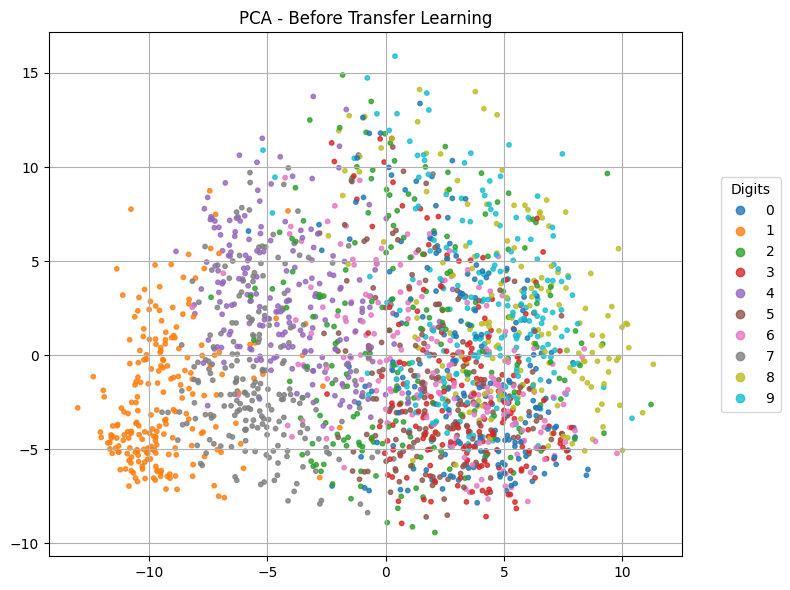

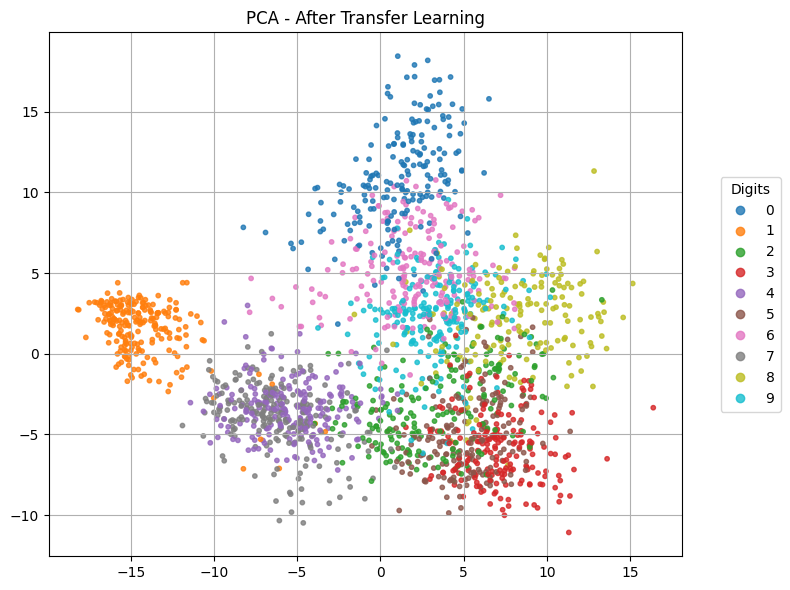

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


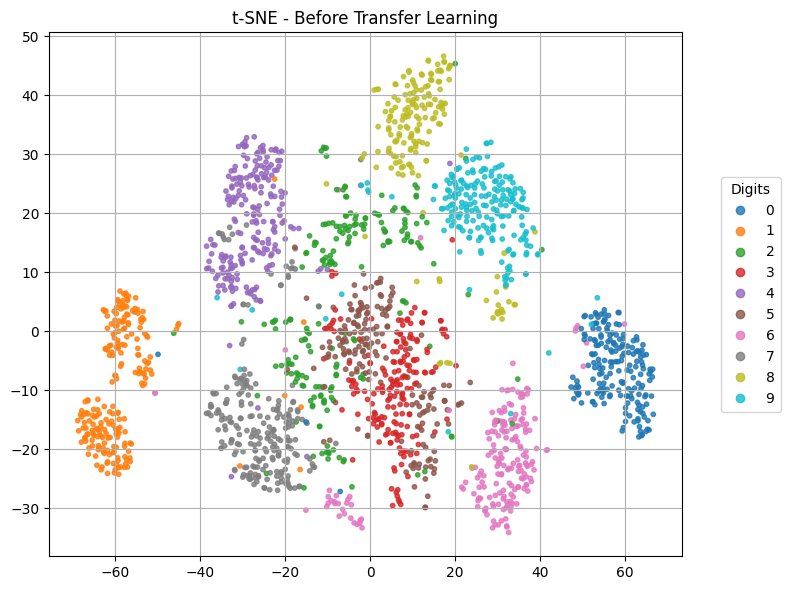

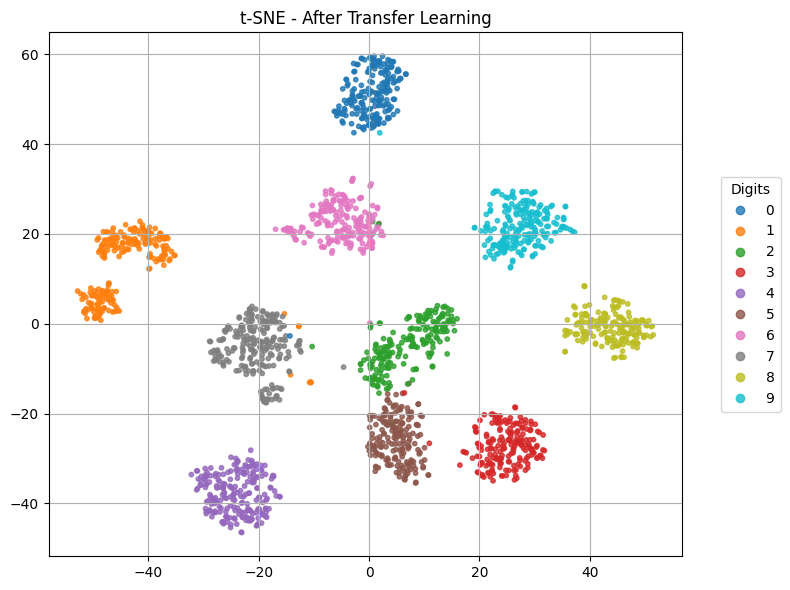

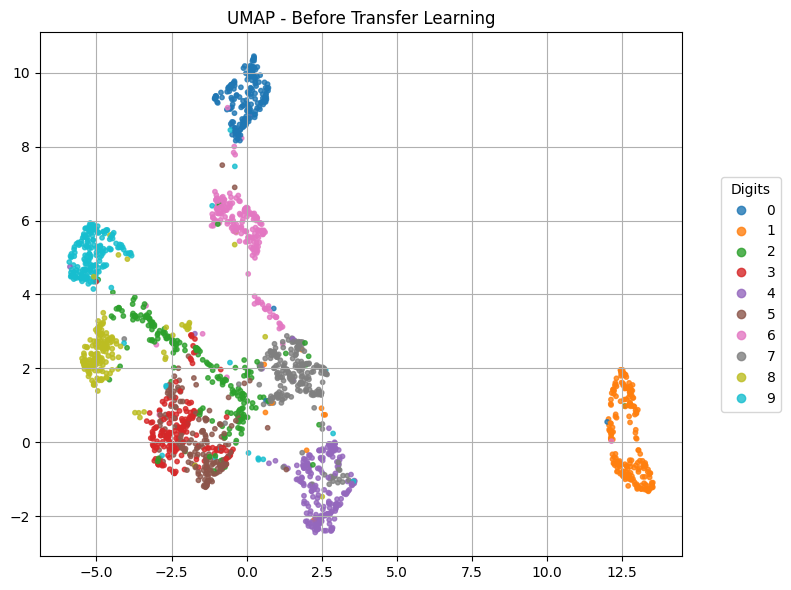

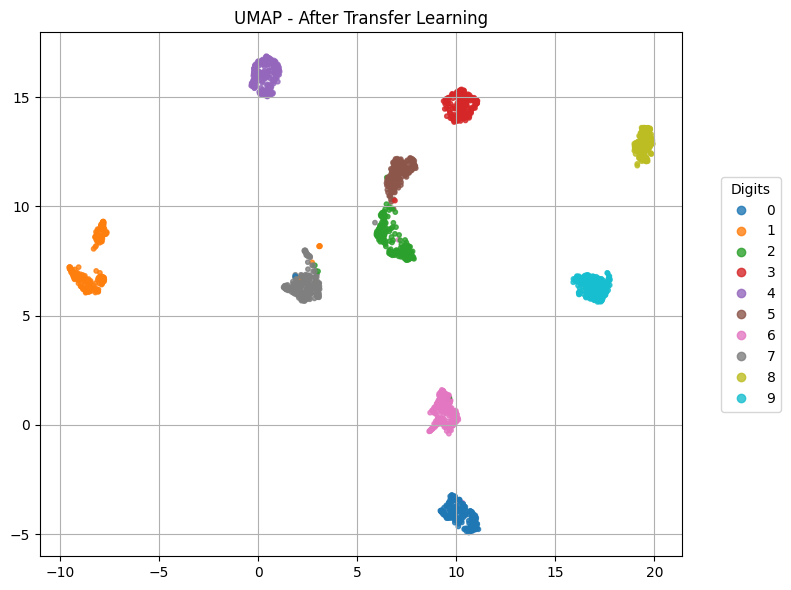

In [7]:
def plot_2d(X, y, title):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=10, alpha=0.8)
    plt.legend(*scatter.legend_elements(), title="Digits",loc='center left', bbox_to_anchor=(1.05, 0.5))
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# PCA
pca = PCA(n_components=2)
pca_before = pca.fit_transform(features_before)
pca_after = pca.fit_transform(features_after)
plot_2d(pca_before, y_subset, "PCA - Before Transfer Learning")
plot_2d(pca_after, y_subset, "PCA - After Transfer Learning")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000)
tsne_before = tsne.fit_transform(features_before)
tsne_after = tsne.fit_transform(features_after)
plot_2d(tsne_before, y_subset, "t-SNE - Before Transfer Learning")
plot_2d(tsne_after, y_subset, "t-SNE - After Transfer Learning")

# UMAP
umap_model = umap.UMAP(n_components=2)
umap_before = umap_model.fit_transform(features_before)
umap_after = umap_model.fit_transform(features_after)
plot_2d(umap_before, y_subset, "UMAP - Before Transfer Learning")
plot_2d(umap_after, y_subset, "UMAP - After Transfer Learning")
